In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import f1_score
import torch
import pandas as pd
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from torch.utils.data import Dataset

# Step 1: Load the train and dev dataset separately
train_data = pd.read_csv('/kaggle/input/racial-hoaxorg/Racial_train.csv')
dev_data = pd.read_csv('/kaggle/input/racial-dev/Racial_val (1).csv')  # Load your dev data here


In [2]:
# Step 2: Define tokenizer and model for MuRIL
murl_model_name = "google/muril-base-cased"
murl_tokenizer = AutoTokenizer.from_pretrained(murl_model_name)
murl_model = AutoModelForSequenceClassification.from_pretrained(murl_model_name, num_labels=2)

# Define tokenizer and model for IndicBERT
indicbert_model_name = "ai4bharat/indic-bert"
indicbert_tokenizer = AutoTokenizer.from_pretrained(indicbert_model_name)
indicbert_model = AutoModelForSequenceClassification.from_pretrained(indicbert_model_name, num_labels=2)


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
# Step 3: Preprocess data (tokenization for both models)
def tokenize_data(text_data, tokenizer):
    text_data_list = text_data.tolist()
    return tokenizer(text_data_list, padding=True, truncation=True, max_length=128, return_tensors='pt')

# Tokenize the training and dev sets
train_encodings_murl = tokenize_data(train_data['clean_text'], murl_tokenizer)
dev_encodings_murl = tokenize_data(dev_data['clean_text'], murl_tokenizer)

train_encodings_indicbert = tokenize_data(train_data['clean_text'], indicbert_tokenizer)
dev_encodings_indicbert = tokenize_data(dev_data['clean_text'], indicbert_tokenizer)

# Convert labels to tensors
train_labels = torch.tensor(train_data['labels'].values)
dev_labels = torch.tensor(dev_data['labels'].values)

In [4]:
# Step 4: Compute class weights to handle the class imbalance
class_weights = compute_class_weight('balanced', classes=[0, 1], y=train_data['labels'])
class_weights = torch.tensor([1.5 * w for w in class_weights], dtype=torch.float)  # Increase the weight for class 1 (minority class)


In [5]:
# Step 5: Define a custom model to include class weights in loss calculation
class WeightedLossModel(AutoModelForSequenceClassification):
    def __init__(self, config, class_weights):
        super().__init__(config)
        self.class_weights = class_weights

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = super().forward(input_ids=input_ids, attention_mask=attention_mask, labels=labels, **kwargs)
        logits = outputs.logits

        # Compute the loss using CrossEntropyLoss with class weights
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            outputs.loss = loss
        return outputs

# Create custom models with class weights
murl_model_weighted = WeightedLossModel.from_pretrained(murl_model_name)
indicbert_model_weighted = WeightedLossModel.from_pretrained(indicbert_model_name)

# Assign class weights to the custom models
murl_model_weighted.class_weights = class_weights
indicbert_model_weighted.class_weights = class_weights

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Step 6: Resample the dataset by oversampling the minority class
train_minority = train_data[train_data['labels'] == 1]
train_majority = train_data[train_data['labels'] == 0]

# Upsample the minority class
train_minority_upsampled = resample(train_minority,
                                    replace=True,
                                    n_samples=len(train_majority),
                                    random_state=42)

# Combine the majority and upsampled minority class
train_balanced = pd.concat([train_majority, train_minority_upsampled])

# Re-tokenize and wrap datasets as before
train_encodings_balanced_murl = tokenize_data(train_balanced['clean_text'], murl_tokenizer)
dev_encodings_murl = tokenize_data(dev_data['clean_text'], murl_tokenizer)
train_encodings_balanced_indicbert = tokenize_data(train_balanced['clean_text'], indicbert_tokenizer)
dev_encodings_indicbert = tokenize_data(dev_data['clean_text'], indicbert_tokenizer)


In [7]:
# Step 7: Dataset Wrapping for Hugging Face Trainer
class RacialHoaxDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Wrap datasets
train_dataset_murl = RacialHoaxDataset(train_encodings_balanced_murl, train_balanced['labels'].tolist())
dev_dataset_murl = RacialHoaxDataset(dev_encodings_murl, dev_data['labels'].tolist())

train_dataset_indicbert = RacialHoaxDataset(train_encodings_balanced_indicbert, train_balanced['labels'].tolist())
dev_dataset_indicbert = RacialHoaxDataset(dev_encodings_indicbert, dev_data['labels'].tolist())

In [8]:
# Step 8: Set up TrainingArguments and Trainer
training_args = TrainingArguments(
    output_dir='/tmp/results',  # Change to a different location with more space
    num_train_epochs=5,
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    warmup_steps=1000,
    weight_decay=0.01,
    logging_dir='/tmp/logs',  # Use a temporary directory for logs
    save_steps=500,  # Save model every 500 steps
    save_strategy="epoch",  # Save at the end of each epoch
    disable_tqdm=False,
    report_to="none"
)

# Trainer for MuRIL model
trainer_murl = Trainer(
    model=murl_model_weighted,  # Use the custom model with class weights
    args=training_args,
    train_dataset=train_dataset_murl,
    eval_dataset=dev_dataset_murl,
    compute_metrics=lambda p: {'f1': f1_score(p.predictions.argmax(-1), p.label_ids, average='macro')}
)

# Trainer for IndicBERT model
trainer_indicbert = Trainer(
    model=indicbert_model_weighted,  # Use the custom model with class weights
    args=training_args,
    train_dataset=train_dataset_indicbert,
    eval_dataset=dev_dataset_indicbert,
    compute_metrics=lambda p: {'f1': f1_score(p.predictions.argmax(-1), p.label_ids, average='macro')}
)

In [9]:
# Step 9: Train the models
trainer_murl.train()

<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss
500,0.692900
1000,0.647100
1500,0.557300
2000,0.505600
2500,0.422500
3000,0.384700
3500,0.430200
4000,0.324800
4500,0.297200
5000,0.262400


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tens

TrainOutput(global_step=5800, training_loss=0.42582671066810346, metrics={'train_runtime': 619.0803, 'train_samples_per_second': 37.459, 'train_steps_per_second': 9.369, 'total_flos': 1525386343449600.0, 'train_loss': 0.42582671066810346, 'epoch': 5.0})

In [10]:
trainer_indicbert.train()

<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss
500,0.692500
1000,0.693200
1500,0.671100
2000,0.625600
2500,0.555900
3000,0.545000
3500,0.562600
4000,0.483700
4500,0.492500
5000,0.405400


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tens

TrainOutput(global_step=5800, training_loss=0.5391029423680799, metrics={'train_runtime': 363.2054, 'train_samples_per_second': 63.848, 'train_steps_per_second': 15.969, 'total_flos': 138549244953600.0, 'train_loss': 0.5391029423680799, 'epoch': 5.0})

In [11]:
# Step 10: Evaluate Both Models
murl_results = trainer_murl.evaluate()
indicbert_results = trainer_indicbert.evaluate()

print("MuRIL Macro F1-Score:", murl_results['eval_f1'])
print("IndicBERT Macro F1-Score:", indicbert_results['eval_f1'])

from sklearn.metrics import accuracy_score
# Predictions for accuracy
muRil_preds_labels = trainer_murl.predict(dev_dataset_murl).predictions.argmax(axis=-1)
indicbert_preds_labels = trainer_indicbert.predict(dev_dataset_indicbert).predictions.argmax(axis=-1)

muRil_acc = accuracy_score(dev_data['labels'], muRil_preds_labels)
indicbert_acc = accuracy_score(dev_data['labels'], indicbert_preds_labels)

print("MuRIL Accuracy:", muRil_acc)
print("IndicBERT Accuracy:", indicbert_acc)


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


MuRIL Macro F1-Score: 0.7004107981220656
IndicBERT Macro F1-Score: 0.6904312540655049


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


MuRIL Accuracy: 0.7845249755142018
IndicBERT Accuracy: 0.7776689520078355


In [12]:
# Step 11: Ensemble (Average)
muRil_preds = trainer_murl.predict(dev_dataset_murl).predictions
indicbert_preds = trainer_indicbert.predict(dev_dataset_indicbert).predictions

final_preds = (muRil_preds + indicbert_preds) / 2
final_labels = final_preds.argmax(axis=-1)

final_f1 = f1_score(dev_data['labels'], final_labels, average='macro')
final_acc = accuracy_score(dev_data['labels'], final_labels)

print(f"Ensemble Macro F1-Score: {final_f1}")
print(f"Ensemble Accuracy: {final_acc}")

<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


<ipython-input-7-d4a846b5cf63>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Ensemble Macro F1-Score: 0.7129557920198601
Ensemble Accuracy: 0.7923604309500489


**Weighted Ensemble**

In [13]:
# Step 12: Weighted Averaging
muRil_f1 = f1_score(dev_data['labels'], muRil_preds_labels, average='macro')
indicbert_f1 = f1_score(dev_data['labels'], indicbert_preds_labels, average='macro')

weights = [muRil_f1, indicbert_f1]
total_weight = sum(weights)
normalized_weights = [w / total_weight for w in weights]

weighted_preds = (muRil_preds * normalized_weights[0]) + (indicbert_preds * normalized_weights[1])
final_preds_weighted = weighted_preds.argmax(axis=-1)

weighted_f1 = f1_score(dev_data['labels'], final_preds_weighted, average='macro')
weighted_acc = accuracy_score(dev_data['labels'], final_preds_weighted)

print(f"Weighted Averaged Macro F1-Score: {weighted_f1}")
print(f"Weighted Averaged Accuracy: {weighted_acc}")

Weighted Averaged Macro F1-Score: 0.7129557920198601
Weighted Averaged Accuracy: 0.7923604309500489


**Stacking**

In [14]:
# Step 13: Stacking
from sklearn.linear_model import LogisticRegression
import numpy as np
stack_X_val = np.hstack((muRil_preds, indicbert_preds))
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(stack_X_val, dev_data['labels'])

stacked_preds = meta_model.predict(stack_X_val)

stacked_f1 = f1_score(dev_data['labels'], stacked_preds, average='macro')
stacked_acc = accuracy_score(dev_data['labels'], stacked_preds)

print(f"Stacked Model Macro F1-Score: {stacked_f1}")
print(f"Stacked Model Accuracy: {stacked_acc}")

Stacked Model Macro F1-Score: 0.682773210926095
Stacked Model Accuracy: 0.8050930460333007


In [15]:
# Check the number of predictions and labels
print("MuRIL Predictions shape:", muRil_preds.shape)
print("IndicBERT Predictions shape:", indicbert_preds.shape)
print("Validation Labels shape:", dev_data['labels'].shape)


MuRIL Predictions shape: (1021, 2)
IndicBERT Predictions shape: (1021, 2)
Validation Labels shape: (1021,)


**Comparison**

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Generate classification reports for each model
muRil_classification_report = classification_report(dev_data['labels'], muRil_preds_labels)
indicbert_classification_report = classification_report(dev_data['labels'], indicbert_preds_labels)
ensemble_classification_report = classification_report(dev_data['labels'], final_labels)
weighted_ensemble_classification_report = classification_report(dev_data['labels'], final_preds_weighted)
stacked_classification_report = classification_report(dev_data['labels'], stacked_preds)

In [17]:
# Print classification reports
print("MuRIL Classification Report:")
print(muRil_classification_report)

MuRIL Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       774
           1       0.56      0.53      0.54       247

    accuracy                           0.78      1021
   macro avg       0.70      0.70      0.70      1021
weighted avg       0.78      0.78      0.78      1021



In [18]:
print("\nIndicBERT Classification Report:")
print(indicbert_classification_report)


IndicBERT Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       774
           1       0.54      0.51      0.53       247

    accuracy                           0.78      1021
   macro avg       0.69      0.69      0.69      1021
weighted avg       0.77      0.78      0.78      1021



In [19]:
print("\nEnsemble Classification Report:")
print(ensemble_classification_report)



Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       774
           1       0.57      0.55      0.56       247

    accuracy                           0.79      1021
   macro avg       0.72      0.71      0.71      1021
weighted avg       0.79      0.79      0.79      1021



In [20]:
print("\nWeighted Ensemble Classification Report:")
print(weighted_ensemble_classification_report)


Weighted Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       774
           1       0.57      0.55      0.56       247

    accuracy                           0.79      1021
   macro avg       0.72      0.71      0.71      1021
weighted avg       0.79      0.79      0.79      1021



In [21]:
print("\nStacked Model Classification Report:")
print(stacked_classification_report)



Stacked Model Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       774
           1       0.67      0.38      0.49       247

    accuracy                           0.81      1021
   macro avg       0.75      0.66      0.68      1021
weighted avg       0.79      0.81      0.78      1021



**Comparison Table**

In [22]:
# Step 2: Create a comparison table for all models' performance
comparison_table = pd.DataFrame({
    "Model": ["MuRIL", "IndicBERT", "Ensemble", "Weighted Ensemble", "Stacked Model"],
    "Accuracy": [muRil_acc, indicbert_acc, final_acc, weighted_acc, stacked_acc],
    "Macro F1-Score": [muRil_f1, indicbert_f1, final_f1, weighted_f1, stacked_f1]
})


In [23]:
# Display the table
print(comparison_table)

               Model  Accuracy  Macro F1-Score
0              MuRIL  0.784525        0.700411
1          IndicBERT  0.777669        0.690431
2           Ensemble  0.792360        0.712956
3  Weighted Ensemble  0.792360        0.712956
4      Stacked Model  0.805093        0.682773


**Plot ROC-AUC curve for each model and ensemble**

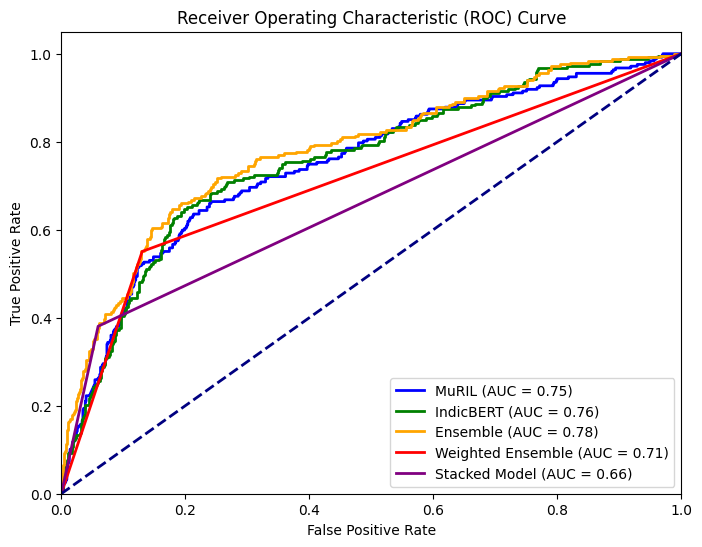

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Convert the predictions into probabilities (apply softmax or sigmoid)
def convert_to_probabilities(predictions):
    if predictions.ndim == 2:  # Logits output from models (multi-class)
        return F.softmax(torch.tensor(predictions), dim=-1)[:, 1]  # Get probabilities for class 1
    elif predictions.ndim == 1:  # If already predicted probabilities for binary class (0 or 1)
        return predictions  # Use the probabilities directly (already in [0, 1] range)
    else:
        raise ValueError("Unknown prediction shape")

# Ensure you are using the predicted probabilities (not class labels)
muRil_probs = convert_to_probabilities(muRil_preds)  # Model output (probabilities or logits)
indicbert_probs = convert_to_probabilities(indicbert_preds)
ensemble_probs = convert_to_probabilities(final_preds)
weighted_ensemble_probs = convert_to_probabilities(final_preds_weighted)
stacked_probs = convert_to_probabilities(stacked_preds)

# Compute ROC curve and AUC for each model
fpr_murl, tpr_murl, _ = roc_curve(dev_data['labels'], muRil_probs)  # Use the probabilities for class 1 directly
fpr_indicbert, tpr_indicbert, _ = roc_curve(dev_data['labels'], indicbert_probs)
fpr_ensemble, tpr_ensemble, _ = roc_curve(dev_data['labels'], ensemble_probs)
fpr_weighted_ensemble, tpr_weighted_ensemble, _ = roc_curve(dev_data['labels'], weighted_ensemble_probs)
fpr_stacked, tpr_stacked, _ = roc_curve(dev_data['labels'], stacked_probs)

# AUC scores
roc_auc_murl = auc(fpr_murl, tpr_murl)
roc_auc_indicbert = auc(fpr_indicbert, tpr_indicbert)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)
roc_auc_weighted_ensemble = auc(fpr_weighted_ensemble, tpr_weighted_ensemble)
roc_auc_stacked = auc(fpr_stacked, tpr_stacked)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_murl, tpr_murl, color='blue', lw=2, label=f'MuRIL (AUC = {roc_auc_murl:.2f})')
plt.plot(fpr_indicbert, tpr_indicbert, color='green', lw=2, label=f'IndicBERT (AUC = {roc_auc_indicbert:.2f})')
plt.plot(fpr_ensemble, tpr_ensemble, color='orange', lw=2, label=f'Ensemble (AUC = {roc_auc_ensemble:.2f})')
plt.plot(fpr_weighted_ensemble, tpr_weighted_ensemble, color='red', lw=2, label=f'Weighted Ensemble (AUC = {roc_auc_weighted_ensemble:.2f})')
plt.plot(fpr_stacked, tpr_stacked, color='purple', lw=2, label=f'Stacked Model (AUC = {roc_auc_stacked:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [25]:
# Step 4: Identify the best performing model (based on accuracy)
best_model_index = np.argmax([muRil_acc, indicbert_acc, final_acc, weighted_acc, stacked_acc])
best_model_name = comparison_table.iloc[best_model_index]['Model']
print(f"Best performing model based on accuracy: {best_model_name}")

Best performing model based on accuracy: Stacked Model


In [26]:
# Step 5: Confusion Matrix for the best model
if best_model_name == 'MuRIL':
    best_preds = muRil_preds_labels
elif best_model_name == 'IndicBERT':
    best_preds = indicbert_preds_labels
elif best_model_name == 'Ensemble':
    best_preds = final_labels
elif best_model_name == 'Weighted Ensemble':
    best_preds = final_preds_weighted
elif best_model_name == 'Stacked Model':
    best_preds = stacked_preds

# Generate confusion matrix
conf_matrix = confusion_matrix(dev_data['labels'], best_preds)


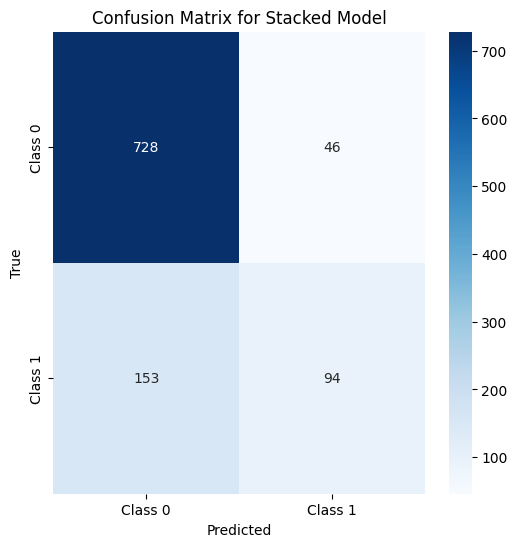

In [27]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
